In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

print("\nEnvironment successfully configured!")

OpenCV version: 5.0.0
NumPy version: 2.4.6

Environment successfully configured!


# Automatic Vehicle Number Plate Detection Using OpenCV

## 1. Introduction

This project aims to develop a computer vision prototype for automatically
detecting vehicle number plates from images using OpenCV.

The system will perform image preprocessing, edge detection, contour analysis,
number plate localisation, and optical character recognition (OCR).

The project will also evaluate the limitations of traditional computer vision
techniques and discuss how modern AI-based approaches could improve the system.

## 2. Import Required Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
image_path = "../data/raw/car1.png"

image = cv2.imread(image_path)

if image is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Image shape:", image.shape)

Image loaded successfully!
Image shape: (427, 247, 3)


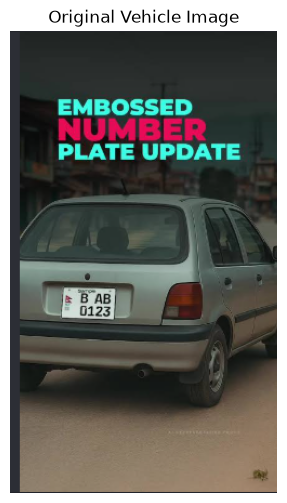

In [5]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original Vehicle Image")
plt.show()

## 3. Image Preprocessing

Image preprocessing is an important step in computer vision because it can
reduce unnecessary information and make subsequent image-processing
operations more efficient.

The first preprocessing step is resizing the input image to a consistent
width while maintaining its aspect ratio.

In [6]:
# Get the original image dimensions
height, width = image.shape[:2]

# Set the desired width
new_width = 800

# Calculate the new height while maintaining the aspect ratio
new_height = int((new_width / width) * height)

# Resize the image
resized_image = cv2.resize(image, (new_width, new_height))

print("Original dimensions:", (width, height))
print("Resized dimensions:", (new_width, new_height))

Original dimensions: (247, 427)
Resized dimensions: (800, 1382)


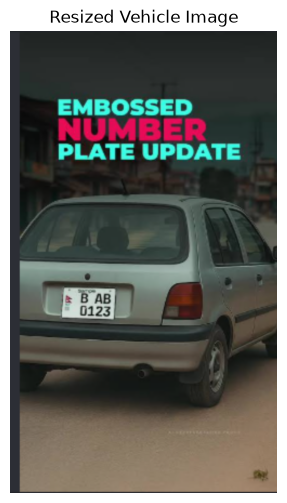

In [7]:
# Convert BGR to RGB for displaying with Matplotlib
resized_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(resized_rgb)
plt.axis("off")
plt.title("Resized Vehicle Image")
plt.show()

### 3.1 Grayscale Conversion

The resized image is converted from a three-channel BGR colour image into a
single-channel grayscale image. Grayscale conversion reduces the amount of
colour information while preserving the intensity information required for
subsequent edge and contour detection.

In [8]:
# Convert the resized image to grayscale
gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

print("Grayscale image shape:", gray_image.shape)

Grayscale image shape: (1382, 800)


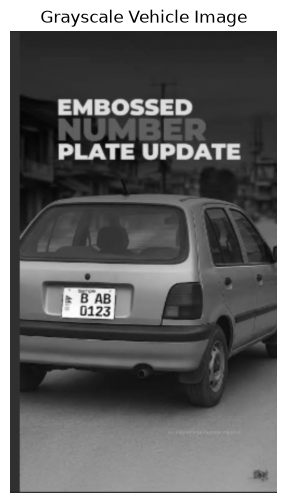

In [9]:
plt.figure(figsize=(12, 6))
plt.imshow(gray_image, cmap="gray")
plt.axis("off")
plt.title("Grayscale Vehicle Image")
plt.show()

## 4. Noise Reduction

Real-world images may contain noise and small intensity variations caused by
camera sensors, compression, lighting, reflections, and background objects.

Gaussian blurring is applied to smooth the grayscale image before edge
detection. This helps reduce insignificant variations and can produce cleaner
edges during the subsequent processing stage.

In [10]:
# Apply Gaussian blur to reduce image noise
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

print("Gaussian blur applied successfully.")

Gaussian blur applied successfully.


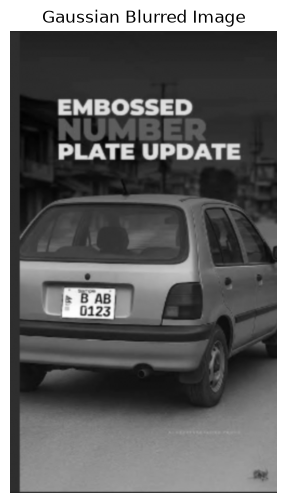

In [11]:
plt.figure(figsize=(12, 6))
plt.imshow(blurred_image, cmap="gray")
plt.axis("off")
plt.title("Gaussian Blurred Image")
plt.show()

## 5. Edge Detection

Canny edge detection is used to identify significant intensity changes in the
image. These changes often correspond to boundaries between different objects
or regions.

For number plate detection, the edges around the rectangular plate region can
provide useful information for identifying potential plate candidates.

In [12]:
# Detect edges using the Canny edge detector
edges = cv2.Canny(blurred_image, 100, 200)

print("Canny edge detection completed.")

Canny edge detection completed.


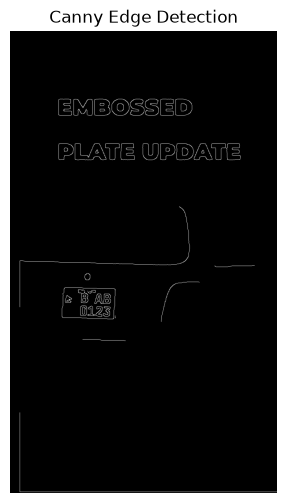

In [13]:
plt.figure(figsize=(12, 6))
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.title("Canny Edge Detection")
plt.show()